<a href="https://colab.research.google.com/github/qjasrubang01-design/Rubang-Jethro-Aaron-S.-CPE-311/blob/main/Midterm_Exam_Skills.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import pandas as pd

customer = pd.read_json('/content/drive/MyDrive/3rd YR 2026 S2/CPE 311 (Data Sci 1)/customers_data.json')

customer

,CustomerID,Name,JoinDate
0,C001,Alice,2022-12-01
1,C002,Bob,2022-11-15
2,C003,Charlie,2023-01-05
3,C004,Diana,2023-01-10
4,C005,Evan,2023-01-20


In [55]:
sale = pd.read_csv('/content/drive/MyDrive/3rd YR 2026 S2/CPE 311 (Data Sci 1)/sales_data_raw.csv')

sale

,TransactionID,CustomerID,TransactionDate,Product,Quantity,Price,Discount
0,T001,C001,2023-01-01,Widget,2,10,0.00
1,T002,C002,2023-01-05,Gadget,1,20,0.10
2,T003,C003,2023-01-07,Widget,3,10,0.00
3,T004,C002,2023-01-10,Gizmo,5,15,0.05
4,T005,C001,2023-01-12,Widget,1,10,0.00
5,T006,C004,2023-01-15,Gadget,2,20,0.20
6,T007,C005,2023-01-18,Widget,4,10,0.00
7,T008,C002,2023-01-20,Gizmo,3,15,0.10
8,T009,C003,2023-01-22,Widget,5,10,0.00
9,T010,C005,2023-01-25,Gadget,3,20,0.15


In [56]:
# Convert TransactionDate to sales data
sale['TransactionDate'] = pd.to_datetime(sale['TransactionDate'])
sale


,TransactionID,CustomerID,TransactionDate,Product,Quantity,Price,Discount
0,T001,C001,2023-01-01,Widget,2,10,0.00
1,T002,C002,2023-01-05,Gadget,1,20,0.10
2,T003,C003,2023-01-07,Widget,3,10,0.00
3,T004,C002,2023-01-10,Gizmo,5,15,0.05
4,T005,C001,2023-01-12,Widget,1,10,0.00
5,T006,C004,2023-01-15,Gadget,2,20,0.20
6,T007,C005,2023-01-18,Widget,4,10,0.00
7,T008,C002,2023-01-20,Gizmo,3,15,0.10
8,T009,C003,2023-01-22,Widget,5,10,0.00
9,T010,C005,2023-01-25,Gadget,3,20,0.15


In [57]:
# Convert JoinData to customer data
customer['JoinDate'] = pd.to_datetime(customer['JoinDate'])

customer

,CustomerID,Name,JoinDate
0,C001,Alice,2022-12-01
1,C002,Bob,2022-11-15
2,C003,Charlie,2023-01-05
3,C004,Diana,2023-01-10
4,C005,Evan,2023-01-20


In [58]:
customer.dtypes

,0
CustomerID,object
Name,object
JoinDate,datetime64[ns]


In [59]:
sale['FinalAmount'] = sale.apply(
    lambda row: final_transaction_amount(row['Quantity'], row['Price'], row['Discount']), axis=1
)

In [60]:
sale.dtypes

,0
TransactionID,object
CustomerID,object
TransactionDate,datetime64[ns]
Product,object
Quantity,int64
Price,int64
Discount,float64
FinalAmount,float64


In [61]:
def final_transaction_amount(Quantity, Price, Discount):
    return (Quantity * Price) - Discount


sale['Final_Amount'] = sale.apply(lambda row: final_transaction_amount(row['Quantity'],row['Price'],row['Discount']),axis=1)

sale

,TransactionID,CustomerID,TransactionDate,Product,Quantity,Price,Discount,FinalAmount,Final_Amount
0,T001,C001,2023-01-01,Widget,2,10,0.00,20.00,20.00
1,T002,C002,2023-01-05,Gadget,1,20,0.10,19.90,19.90
2,T003,C003,2023-01-07,Widget,3,10,0.00,30.00,30.00
3,T004,C002,2023-01-10,Gizmo,5,15,0.05,74.95,74.95
4,T005,C001,2023-01-12,Widget,1,10,0.00,10.00,10.00
5,T006,C004,2023-01-15,Gadget,2,20,0.20,39.80,39.80
6,T007,C005,2023-01-18,Widget,4,10,0.00,40.00,40.00
7,T008,C002,2023-01-20,Gizmo,3,15,0.10,44.90,44.90
8,T009,C003,2023-01-22,Widget,5,10,0.00,50.00,50.00
9,T010,C005,2023-01-25,Gadget,3,20,0.15,59.85,59.85


In [62]:
merged_data = pd.merge(sale, customer, on='CustomerID', how='left')

merged_data

,TransactionID,CustomerID,TransactionDate,Product,Quantity,Price,Discount,FinalAmount,Final_Amount,Name,JoinDate
0,T001,C001,2023-01-01,Widget,2,10,0.00,20.00,20.00,Alice,2022-12-01
1,T002,C002,2023-01-05,Gadget,1,20,0.10,19.90,19.90,Bob,2022-11-15
2,T003,C003,2023-01-07,Widget,3,10,0.00,30.00,30.00,Charlie,2023-01-05
3,T004,C002,2023-01-10,Gizmo,5,15,0.05,74.95,74.95,Bob,2022-11-15
4,T005,C001,2023-01-12,Widget,1,10,0.00,10.00,10.00,Alice,2022-12-01
5,T006,C004,2023-01-15,Gadget,2,20,0.20,39.80,39.80,Diana,2023-01-10
6,T007,C005,2023-01-18,Widget,4,10,0.00,40.00,40.00,Evan,2023-01-20
7,T008,C002,2023-01-20,Gizmo,3,15,0.10,44.90,44.90,Bob,2022-11-15
8,T009,C003,2023-01-22,Widget,5,10,0.00,50.00,50.00,Charlie,2023-01-05
9,T010,C005,2023-01-25,Gadget,3,20,0.15,59.85,59.85,Evan,2023-01-20


In [63]:
sale = sale.drop_duplicates()

sale

,TransactionID,CustomerID,TransactionDate,Product,Quantity,Price,Discount,FinalAmount,Final_Amount
0,T001,C001,2023-01-01,Widget,2,10,0.00,20.00,20.00
1,T002,C002,2023-01-05,Gadget,1,20,0.10,19.90,19.90
2,T003,C003,2023-01-07,Widget,3,10,0.00,30.00,30.00
3,T004,C002,2023-01-10,Gizmo,5,15,0.05,74.95,74.95
4,T005,C001,2023-01-12,Widget,1,10,0.00,10.00,10.00
5,T006,C004,2023-01-15,Gadget,2,20,0.20,39.80,39.80
6,T007,C005,2023-01-18,Widget,4,10,0.00,40.00,40.00
7,T008,C002,2023-01-20,Gizmo,3,15,0.10,44.90,44.90
8,T009,C003,2023-01-22,Widget,5,10,0.00,50.00,50.00
9,T010,C005,2023-01-25,Gadget,3,20,0.15,59.85,59.85


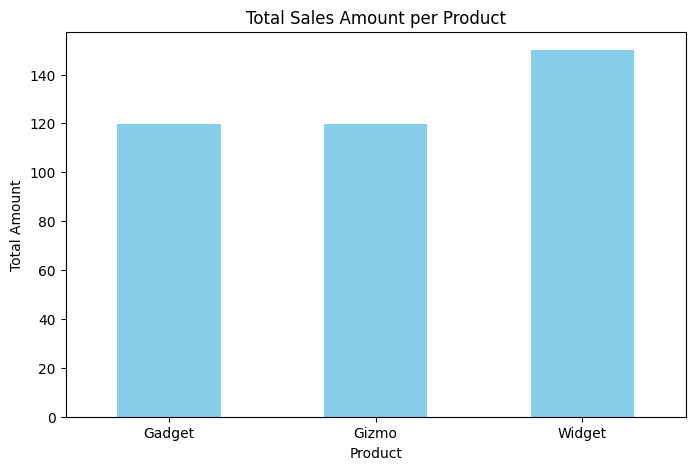

In [64]:
import matplotlib.pyplot as plt

total_sales = sale.groupby('Product')['Final_Amount'].sum()

# Plot bar chart
plt.figure(figsize=(8,5))
total_sales.plot(kind='bar', color='skyblue')
plt.title('Total Sales Amount per Product')
plt.xlabel('Product')
plt.ylabel('Total Amount')
plt.xticks(rotation=0)
plt.show()

In [67]:
# Save as CSV
sale.to_csv('/content/drive/MyDrive/3rd YR 2026 S2/CPE 311 (Data Sci 1)/Midterms Exam Skills/transformed_sales.csv', index=False)

# Save as Excel
sale.to_excel('/content/drive/MyDrive/3rd YR 2026 S2/CPE 311 (Data Sci 1)/Midterms Exam Skills/transformed_sales.xlsx', index=False)

# Save as JSON
sale.to_json('/content/drive/MyDrive/3rd YR 2026 S2/CPE 311 (Data Sci 1)/Midterms Exam Skills/transformed_sales.json', orient='records', lines=True)

In [68]:
# Check for the missing values
print(sale.isna().sum())
print(customer.isna().sum())

# fill missing Discount with 0
sale['Discount'] = sale['Discount'].fillna(0)

TransactionID      0
CustomerID         0
TransactionDate    0
Product            0
Quantity           0
Price              0
Discount           0
FinalAmount        0
Final_Amount       0
dtype: int64
CustomerID    0
Name          0
JoinDate      0
dtype: int64


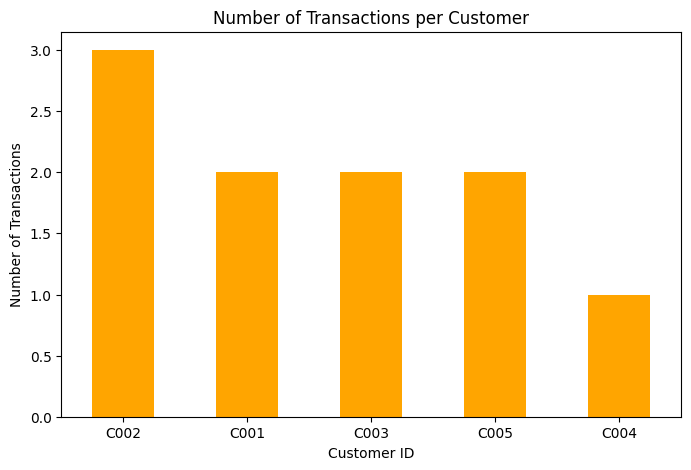

In [70]:
transaction_count = sale['CustomerID'].value_counts()

plt.figure(figsize=(8,5))
transaction_count.plot(kind='bar', color='orange')
plt.title('Number of Transactions per Customer')
plt.xlabel('Customer ID')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.show()